In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

### Function Description

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.

Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.

Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

In [2]:
# Load data
X = np.load('initial_inputs.npy')
Y = np.load('initial_outputs.npy')

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2', 'x3'])
df['target'] = Y

print(df.describe())

              x1         x2         x3     target
count  15.000000  15.000000  15.000000  15.000000
mean    0.409031   0.517677   0.402788  -0.107167
std     0.275039   0.232950   0.284142   0.087170
min     0.046809   0.219917   0.066089  -0.398926
25%     0.171001   0.320871   0.236298  -0.112995
50%     0.345523   0.439991   0.272433  -0.105965
75%     0.622800   0.684509   0.512518  -0.052383
max     0.965995   0.941360   0.990882  -0.034835


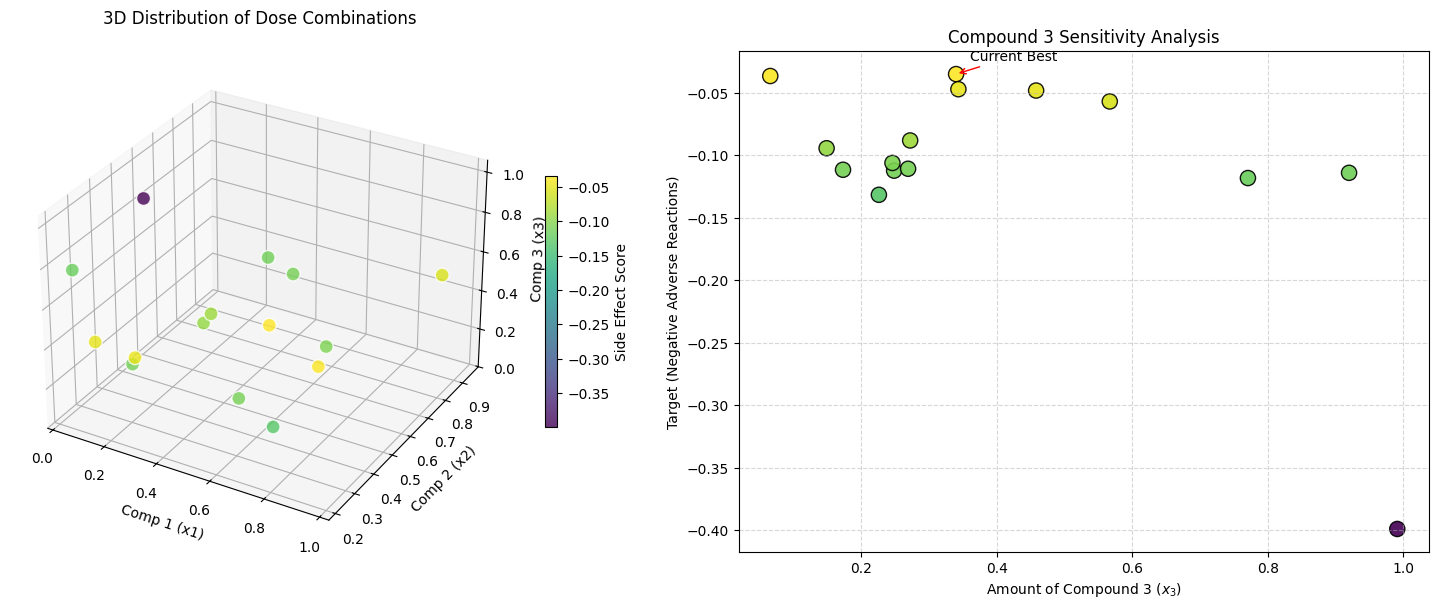

In [4]:
# Setup the dual-plot figure
fig = plt.figure(figsize=(15, 6))

# Plot A: 3D Scatter (The "Cube")
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X[:,0], X[:,1], X[:,2], c=Y, cmap='viridis', s=100, edgecolor='w', alpha=0.8)
ax1.set_xlabel('Comp 1 (x1)')
ax1.set_ylabel('Comp 2 (x2)')
ax1.set_zlabel('Comp 3 (x3)')
ax1.set_title('3D Distribution of Dose Combinations', pad=20)
plt.colorbar(scatter1, ax=ax1, label='Side Effect Score', shrink=0.5)

# Plot B: Sensitivity Projection (x3 vs Target)
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(X[:,2], Y, c=Y, cmap='viridis', s=120, edgecolor='k', alpha=0.9)
ax2.set_xlabel('Amount of Compound 3 ($x_3$)')
ax2.set_ylabel('Target (Negative Adverse Reactions)')
ax2.set_title('Compound 3 Sensitivity Analysis')
ax2.grid(True, linestyle='--', alpha=0.5)

# Highlight the best point
best_idx = np.argmax(Y)
ax2.annotate('Current Best', (X[best_idx, 2], Y[best_idx]), xytext=(10, 10), 
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

In [5]:
# Kernel with ARD (one length scale per dimension)
# We use Matern 2.5 for a "smooth but realistic" drug interaction surface
kernel = Matern(length_scale=[0.5, 0.5, 0.5], length_scale_bounds=(0.1, 2.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-2))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=42
)

model.fit(X, Y)

# 3. 3D Grid Search (Warning: Grid grows fast! 40x40x40 = 64,000 points)
res = 40 
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
x3 = np.linspace(0, 1, res)
X1, X2, X3 = np.meshgrid(x1, x2, x3)
grid_points = np.vstack([X1.ravel(), X2.ravel(), X3.ravel()]).T

# 4. Predict and optimize with UCB
beta = 0.5
mean, std = model.predict(grid_points, return_std=True)
ucb = mean + beta * std

best_idx = np.argmax(ucb)
suggestion = grid_points[best_idx]

print(f"--- Function 3 (Drug Discovery) ---")
print(f"Suggested Dose: Compound 1={suggestion[0]:.4f}, Compound 2={suggestion[1]:.4f}, Compound 3={suggestion[2]:.4f}")
print(f"Predicted Score: {mean[best_idx]:.4f} (UCB: {ucb[best_idx]:.4f})")

--- Function 3 (Drug Discovery) ---
Suggested Dose: Compound 1=0.5385, Compound 2=0.4615, Compound 3=0.4103
Predicted Score: -0.0222 (UCB: -0.0009)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [6]:
betas = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
sweep_results = []

for b in betas:
    ucb = mean + b * std
    best_idx = np.argmax(ucb)
    coords = grid_points[best_idx]
    
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': mean[best_idx],
        'Uncertainty': std[best_idx]
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

# 7. Model Diagnostic
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
      Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)   Pred Mean  Uncertainty
0.10000000   0.48717949   0.48717949   0.41025641 -0.02136118   0.04025461
0.50000000   0.53846154   0.46153846   0.41025641 -0.02217623   0.04264900
1.00000000   0.58974359   0.43589744   0.43589744 -0.02816795   0.05297798
1.50000000   0.61538462   0.00000000   0.46153846 -0.03777126   0.06062878
2.00000000   0.64102564   0.00000000   0.46153846 -0.03878154   0.06126865
2.50000000   1.00000000   0.00000000   0.76923077 -0.07572964   0.07773970
3.00000000   1.00000000   0.00000000   0.76923077 -0.07572964   0.07773970
3.50000000   1.00000000   0.00000000   0.76923077 -0.07572964   0.07773970

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.446, 2, 0.13], nu=2.5) + WhiteKernel(noise_level=0.01)


### Week 1 submission: x1 = 0.6410, x2 = 0.0000, x3 = 0.4615 ; Beta = 2.0

* The Problem Framing: We are optimizing a 3D space (three compounds). The target is the negative of adverse reactions. Our goal is to get as close to 0 as possible.

* The Surrogate Model: Matern 2.5 + ARD (Automatic Relevance Determination).
    * Logic: We assumed chemical interactions are continuous (Matern). By using ARD, we gave the model a separate "sensitivity" slider (length scale) for each compound. 

* The Baseline Fix: normalize_y=True.
    * All results are negative (−0.39 to −0.03). Without normalization, the model would assume the "default" for unexplored areas is 0, causing it to ignore our data and chase corners indefinitely.

* Noise Management: WhiteKernel.
    * The WhiteKernel prevents the model from "overfitting" to a single lucky result, ensuring we find a broad "safe shelf" rather than a single fluke coordinate.

* Acquisition Function: Upper Confidence Bound (UCB).
    * Formula: UCB(x)=μ(x)+βσ(x)

* Key Insight from Data: Compound 3 (x3​) appeared to be a toxicity trigger in early samples (x3​>0.7 led to sharp drops). Compound 2 (x2​) showed signs of being potentially unnecessary, as the model suggested cutting it to 0.0 at moderate Beta levels to see if safety improved.

* This setup is designed to be self-correcting; if we query a high dose and it turns out to be safe, the ARD will automatically re-scale the dimensions to stop being "scared" of that compound.

In [7]:
# ---------------------------------------------------
# WEEK1: NEW DATA HERE
# ---------------------------------------------------
w1_new_input = [0.641, 0.0, 0.4615]
w1_new_output = -0.07105442907739996

new_X = np.array(w1_new_input).reshape(1, -1)
new_Y = np.atleast_1d(w1_new_output)

X_updated_w1 = np.vstack((X, new_X))
Y_updated_w1 = np.append(Y, new_Y)

df = pd.DataFrame(X_updated_w1, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w1

print(df.describe())
print(df.head(16))

              x1         x2         x3     target
count  16.000000  16.000000  16.000000  16.000000
mean    0.423529   0.485322   0.406457  -0.104910
std     0.271968   0.259610   0.274899   0.084697
min     0.046809   0.000000   0.066089  -0.398926
25%     0.171263   0.294418   0.241296  -0.112559
50%     0.419052   0.419246   0.306305  -0.100077
75%     0.642126   0.678247   0.487832  -0.054571
max     0.965995   0.941360   0.990882  -0.034835
          x1        x2        x3    target
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -

In [8]:
kernel = Matern(length_scale=[0.5, 0.5, 0.5], length_scale_bounds=(0.1, 2.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-2))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=42
)

model.fit(X_updated_w1, Y_updated_w1)

res = 40 
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
x3 = np.linspace(0, 1, res)
X1, X2, X3 = np.meshgrid(x1, x2, x3)
grid_points = np.vstack([X1.ravel(), X2.ravel(), X3.ravel()]).T

beta = 0.5
mean, std = model.predict(grid_points, return_std=True)
ucb = mean + beta * std

best_idx = np.argmax(ucb)
suggestion = grid_points[best_idx]

betas = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
sweep_results = []

for b in betas:
    ucb = mean + b * std
    best_idx = np.argmax(ucb)
    coords = grid_points[best_idx]
    
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': mean[best_idx],
        'Uncertainty': std[best_idx]
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.100000     0.435897     0.615385     0.384615  -0.028721     0.026451
0.500000     0.435897     0.923077     0.384615  -0.030888     0.032675
1.000000     0.384615     1.000000     0.000000  -0.045712     0.057544
1.500000     0.307692     1.000000     0.000000  -0.051335     0.062166
2.000000     1.000000     0.461538     0.769231  -0.073288     0.075889
2.500000     1.000000     0.307692     0.769231  -0.073479     0.075969
3.000000     1.000000     0.000000     0.769231  -0.074424     0.076324
3.500000     1.000000     0.000000     0.769231  -0.074424     0.076324

--- Optimized Kernel Parameters ---
Matern(length_scale=[0.451, 2, 0.125], nu=2.5) + WhiteKernel(noise_level=0.01)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 2 submission:

* The Strategy: We are maintaining a high-exploration weight of β=2.

* The model suggests that the best results may not be in the center of the mixture, but rather at a high concentration of Compound A combined with a high dose of the sensitive Compound C.

* The Chosen Query: [1.00000000, 0.46153846, 0.76923077]
    * Compound A (x1​): Maximized at 1.0 to test the limit of this compound's safety profile.
    * Compound B (x2​): Kept at a moderate 0.4615 to verify if it truly remains as "lazy" (low impact) as the current length scale suggests.
    * Compound C (x3​): Pushed to 0.7692, testing the "surgical" sensitivity of the most volatile variable in the mix.

In [9]:
# ---------------------------------------------------
# WEEK2: NEW DATA HERE
# ---------------------------------------------------

w2_new_input = [1.000000, 0.461538, 0.769231]
w2_new_output = np.float64(-0.10243650260928291)

w2_new_X = np.atleast_2d(w2_new_input)
w2_new_Y = np.atleast_1d(w2_new_output)

X_updated_w2 = np.vstack((X_updated_w1, w2_new_X))
Y_updated_w2 = np.append(Y_updated_w1, w2_new_Y)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_updated_w2_scaled = scaler_x.fit_transform(X_updated_w2)
Y_updated_w2_scaled = scaler_y.fit_transform(Y_updated_w2.reshape(-1, 1))

df = pd.DataFrame(X_updated_w2, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w2

# print(df.describe())
print(df.head(17))

          x1        x2        x3    target
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.641000  0.000000  0.461500 -0.071054
16  1.000000  0.461538  0.769231 -0.102437


In [10]:
kernel = Matern(length_scale=[0.5, 0.5, 0.5], length_scale_bounds=(0.1, 5.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-2))

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    random_state=42
)

model.fit(X_updated_w2_scaled, Y_updated_w2_scaled)

res = 40 
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
x3 = np.linspace(0, 1, res)
X1, X2, X3 = np.meshgrid(x1, x2, x3)
grid_points = np.vstack([X1.ravel(), X2.ravel(), X3.ravel()]).T
grid_points_scaled = scaler_x.transform(grid_points)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.100000     0.743590     0.564103     0.333333  -0.034698     0.019944
0.500000     1.000000     0.384615     0.333333  -0.039357     0.037896
1.000000     0.564103     1.000000     0.384615  -0.055037     0.062005
1.500000     0.179487     1.000000     0.410256  -0.059432     0.066195
2.000000     0.333333     1.000000     0.410256  -0.059943     0.066472
2.500000     0.769231     1.000000     0.410256  -0.064031     0.068247
3.000000     0.000000     0.000000     0.000000  -0.084225     0.075822
3.500000     0.000000     0.000000     0.000000  -0.084225     0.075822

--- Optimized Kernel Parameters ---
Matern(length_scale=[5, 5, 0.192], nu=2.5) + WhiteKernel(noise_level=1e-05)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 3 submission:

* Standardised the whole dataset across x and y before running the bayesian optimisation. 

* Selected Coordinate: Locked in the β=1.5 suggestion (x1​=0.435897,x2​=0.641026,x3​=0.461538).

* Strategic Phase: Shifting into a transitional phase, moving gradually from wide-net exploration toward targeted exploitation.


In [11]:
# ---------------------------------------------------
# WEEK3: NEW DATA HERE
# ---------------------------------------------------

w3_new_input = [0.435897, 0.641026, 0.461538]
w3_new_output = -0.017906029586548047

w3_new_X = np.atleast_2d(w3_new_input)
w3_new_Y = np.atleast_1d(w3_new_output)

X_updated_w3 = np.vstack((X_updated_w2, w3_new_X))
Y_updated_w3 = np.append(Y_updated_w2, w3_new_Y)

X_updated_w3_scaled = scaler_x.fit_transform(X_updated_w3)
Y_updated_w3_scaled = scaler_y.fit_transform(Y_updated_w3.reshape(-1, 1))

df = pd.DataFrame(X_updated_w3, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w3

print(df.describe())

              x1         x2         x3     target
count  18.000000  18.000000  18.000000  18.000000
mean    0.456242   0.492651   0.429671  -0.099939
std     0.289290   0.246720   0.272081   0.082153
min     0.046809   0.000000   0.066089  -0.398926
25%     0.183781   0.309348   0.246906  -0.111945
50%     0.464239   0.450764   0.341866  -0.098313
75%     0.644377   0.665007   0.540506  -0.050195
max     1.000000   0.941360   0.990882  -0.017906


In [12]:
kernel = Matern(length_scale=[0.5, 0.5, 0.5], length_scale_bounds=(0.01, 100.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1.0))

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    random_state=42
)

model.fit(X_updated_w3_scaled, Y_updated_w3_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5, 1.0, 1.5]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.010000     0.000000     1.000000     0.461538  -0.009965     0.017324
0.050000     0.000000     1.000000     0.461538  -0.009965     0.017324
0.100000     0.000000     1.000000     0.435897  -0.012124     0.040126
0.200000     0.000000     1.000000     0.435897  -0.012124     0.040126
0.400000     0.000000     1.000000     0.435897  -0.012124     0.040126
0.500000     0.000000     1.000000     0.435897  -0.012124     0.040126
1.000000     0.000000     1.000000     0.410256  -0.024794     0.056832
1.500000     0.000000     1.000000     0.410256  -0.024794     0.056832

--- Optimized Kernel Parameters ---
Matern(length_scale=[100, 5.59, 0.222], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 4 submission:

Next point to query [0.000000, 1.000000, 0.435897] beta = 0.2 - 0.5

* The last query was succesful, it improved on the best existing data point. Going further into optmization 
* Updated the kernel by increasing the length scale bound to 100 - x1 is super irrelevant. x2 is also irrelevant but less.
* Updated the noise bound from 0.01 to 1.0 on the upper side and lowered it on the low side - the kernel still hits the boundary on the lower side. 
* Basically allowed the model to "operate" and not run against walls. 
 

In [13]:
# ---------------------------------------------------
# WEEK4: NEW DATA HERE
# ---------------------------------------------------

w4_new_input = 	[0.000000, 1.000000, 0.435897]
w4_new_output = -0.050775023436100374

w4_new_X = np.atleast_2d(w4_new_input)
w4_new_Y = np.atleast_1d(w4_new_output)

X_updated_w4 = np.vstack((X_updated_w3, w4_new_X))
Y_updated_w4 = np.append(Y_updated_w3, w4_new_Y)

X_updated_w4_scaled = scaler_x.fit_transform(X_updated_w4)
Y_updated_w4_scaled = scaler_y.fit_transform(Y_updated_w4.reshape(-1, 1))

df = pd.DataFrame(X_updated_w4, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w4

print(df.describe())

              x1         x2         x3     target
count  19.000000  19.000000  19.000000  19.000000
mean    0.432230   0.519353   0.429999  -0.097351
std     0.299992   0.266527   0.264420   0.080631
min     0.000000   0.000000   0.066089  -0.398926
25%     0.171001   0.320871   0.247516  -0.111768
50%     0.435897   0.461538   0.343555  -0.094190
75%     0.643251   0.684509   0.514184  -0.049391
max     1.000000   1.000000   0.990882  -0.017906


In [14]:
kernel = Matern(length_scale=[0.5, 0.5, 0.5], length_scale_bounds=(0.01, 100.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1.0))

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    random_state=42
)

model.fit(X_updated_w4_scaled, Y_updated_w4_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [0.01, 0.05, 0.1, 0.2, 0.4, 0.5, 1.0, 1.5]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.010000     0.000000     0.743590     0.461538  -0.015520     0.006165
0.050000     0.000000     0.846154     0.487179  -0.016620     0.032522
0.100000     0.000000     0.871795     0.487179  -0.016676     0.033113
0.200000     0.000000     0.871795     0.487179  -0.016676     0.033113
0.400000     0.000000     0.923077     0.487179  -0.017067     0.034448
0.500000     0.000000     0.948718     0.487179  -0.017394     0.035185
1.000000     0.000000     1.000000     0.487179  -0.018290     0.036773
1.500000     0.000000     1.000000     0.512821  -0.032931     0.050832

--- Optimized Kernel Parameters ---
Matern(length_scale=[100, 4.93, 0.219], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 5 submission:

Next point to query: [0.000000 0.846154 0.487179] beta = 0.05

* Possible that we have found this local max
* Trying again with an extremely low beta to see if there's anything to capture 

In [15]:
# ---------------------------------------------------
# WEEK5: NEW DATA HERE
# ---------------------------------------------------

w5_new_input = 	[0.000000, 0.846154, 0.487179]
w5_new_output = -0.04934690880351635

w5_new_X = np.atleast_2d(w5_new_input)
w5_new_Y = np.atleast_1d(w5_new_output)

X_updated_w5 = np.vstack((X_updated_w4, w5_new_X))
Y_updated_w5 = np.append(Y_updated_w4, w5_new_Y)

X_updated_w5_scaled = scaler_x.fit_transform(X_updated_w5)
Y_updated_w5_scaled = scaler_y.fit_transform(Y_updated_w5.reshape(-1, 1))

df = pd.DataFrame(X_updated_w5, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w5

print(df.describe())

              x1         x2         x3     target
count  20.000000  20.000000  20.000000  20.000000
mean    0.410618   0.535693   0.432858  -0.094951
std     0.307570   0.269514   0.257684   0.079211
min     0.000000   0.000000   0.066089  -0.398926
25%     0.165817   0.332394   0.248127  -0.111592
50%     0.390710   0.536566   0.389726  -0.091076
75%     0.642126   0.704058   0.507092  -0.049012
max     1.000000   1.000000   0.990882  -0.017906


In [16]:
model.fit(X_updated_w5_scaled, Y_updated_w5_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [ 0.5, 1.0, 1.5, 2.5, 3.0, 5.0]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.500000     0.000000     0.871795     0.461538  -0.018108     0.012678
1.000000     0.000000     0.000000     0.000000  -0.055951     0.057770
1.500000     0.000000     0.000000     0.000000  -0.055951     0.057770
2.500000     1.000000     1.000000     0.666667  -0.084929     0.075203
3.000000     1.000000     1.000000     0.666667  -0.084929     0.075203
5.000000     1.000000     1.000000     0.666667  -0.084929     0.075203

--- Optimized Kernel Parameters ---
Matern(length_scale=[100, 5.07, 0.2], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 6 submission

Next point to query: [1.000000 1.000000 0.666667] beta = 2.5 - 5.0 

* The optimisation isn't yielding and improvements anymore
* Going back to exploration 

In [17]:
# ---------------------------------------------------
# WEEK6: NEW DATA HERE
# ---------------------------------------------------

w6_new_input = 	[1.000000, 1.000000, 0.666667]
w6_new_output = -0.15046741058640586

w6_new_X = np.atleast_2d(w6_new_input)
w6_new_Y = np.atleast_1d(w6_new_output)

X_updated_w6 = np.vstack((X_updated_w5, w6_new_X))
Y_updated_w6 = np.append(Y_updated_w5, w6_new_Y)

X_updated_w6_scaled = scaler_x.fit_transform(X_updated_w6)
Y_updated_w6_scaled = scaler_y.fit_transform(Y_updated_w6.reshape(-1, 1))

df = pd.DataFrame(X_updated_w6, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w6

print(df.head(21))

          x1        x2        x3    target
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.641000  0.000000  0.461500 -0.071054
16  1.000000  0.461538  0.769231 -0.102437
17  0.435897  0.641026  0.461538 -0.017906
18  0.000000  1.000000  0.435897 -0.050775
19  0.000000  0.846154  0.487179 -0.049347
20  1.000000  1.000000  0.666667 -0.150467


In [18]:
model.fit(X_updated_w6_scaled, Y_updated_w6_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [ 0.25, 0.5, 1.0, 1.5, 2.5, 3.0, 5.0]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.250000     1.000000     0.692308     0.435897  -0.021655     0.008899
0.500000     1.000000     0.717949     0.435897  -0.021765     0.009151
1.000000     0.000000     0.000000     0.000000  -0.051308     0.049884
1.500000     0.000000     0.000000     0.000000  -0.051308     0.049884
2.500000     1.000000     1.000000     0.871795  -0.084042     0.071496
3.000000     1.000000     1.000000     0.871795  -0.084042     0.071496
5.000000     1.000000     1.000000     0.871795  -0.084042     0.071496

--- Optimized Kernel Parameters ---
Matern(length_scale=[100, 4.84, 0.196], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 7 submission

Next point to query [1.000000 0.692308 0.435897] beta = 0.25

* Dimension cutting and dataset sampling in the next round. 

In [19]:
# ---------------------------------------------------
# WEEK7: NEW DATA HERE
# ---------------------------------------------------

w7_new_input = 	[1.000000, 0.692308, 0.435897]
w7_new_output = -0.011060464483582737

w7_new_X = np.atleast_2d(w7_new_input)
w7_new_Y = np.atleast_1d(w7_new_output)

X_updated_w7 = np.vstack((X_updated_w6, w7_new_X))
Y_updated_w7 = np.append(Y_updated_w6, w7_new_Y)

X_updated_w7_scaled = scaler_x.fit_transform(X_updated_w7)
Y_updated_w7_scaled = scaler_y.fit_transform(Y_updated_w7.reshape(-1, 1))

df = pd.DataFrame(X_updated_w7, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w7

print(df.describe())
# print(df.head(22))

              x1         x2         x3     target
count  22.000000  22.000000  22.000000  22.000000
mean    0.464198   0.563917   0.443624  -0.093661
std     0.340096   0.276259   0.250119   0.078466
min     0.000000   0.000000   0.066089  -0.398926
25%     0.170739   0.357223   0.253894  -0.111945
50%     0.464239   0.626310   0.435897  -0.091076
75%     0.660886   0.718110   0.546917  -0.048342
max     1.000000   1.000000   0.990882  -0.011060


In [20]:
model.fit(X_updated_w7_scaled, Y_updated_w7_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [ 0.01, 0.10, 0.25, 0.5]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.010000     1.000000     0.487179     0.410256  -0.008682     0.009076
0.100000     1.000000     0.487179     0.410256  -0.008682     0.009076
0.250000     1.000000     0.461538     0.410256  -0.008840     0.010208
0.500000     1.000000     0.435897     0.410256  -0.009390     0.011426

--- Optimized Kernel Parameters ---
Matern(length_scale=[65.8, 3.5, 0.275], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


### Week 8 submission

Next point to query [1.000000 0.487179 0.410256] beta = 0.01 - 0.1

* New best point!
* Optimize further
* Apply dimension freezing and data masking if cannot optimize further

In [21]:
# ---------------------------------------------------
# WEEK8: NEW DATA HERE
# ---------------------------------------------------

w8_new_input = 	[1.000000, 0.487179, 0.410256]
w8_new_output = -0.024446301689280137

w8_new_X = np.atleast_2d(w8_new_input)
w8_new_Y = np.atleast_1d(w8_new_output)

X_updated_w8 = np.vstack((X_updated_w7, w8_new_X))
Y_updated_w8 = np.append(Y_updated_w7, w8_new_Y)

X_updated_w8_scaled = scaler_x.fit_transform(X_updated_w8)
Y_updated_w8_scaled = scaler_y.fit_transform(Y_updated_w8.reshape(-1, 1))

df = pd.DataFrame(X_updated_w8, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w8

print(df.describe())

              x1         x2         x3     target
count  23.000000  23.000000  23.000000  23.000000
mean    0.487494   0.560581   0.442173  -0.090652
std     0.350557   0.270381   0.244467   0.078009
min     0.000000   0.000000   0.066089  -0.398926
25%     0.171001   0.370530   0.259050  -0.111768
50%     0.492581   0.611593   0.435897  -0.087963
75%     0.706463   0.711084   0.527004  -0.047477
max     1.000000   1.000000   0.990882  -0.011060


In [22]:
model.fit(X_updated_w8_scaled, Y_updated_w8_scaled)

mean_scaled, std_scaled = model.predict(grid_points_scaled, return_std=True)
mean_scaled = mean_scaled.flatten()
std_scaled = std_scaled.flatten()

betas = [ 0.01, 0.10, 0.25, 0.5]
sweep_results = []

for b in betas:
    ucb_scaled = mean_scaled + (b * std_scaled)
    best_idx = np.argmax(ucb_scaled)
    coords = grid_points[best_idx]
    actual_mean = scaler_y.inverse_transform([[mean_scaled[best_idx]]])[0][0]
    actual_std = std_scaled[best_idx] * scaler_y.scale_[0]
    sweep_results.append({
        'Beta': b,
        'x1 (Comp A)': coords[0],
        'x2 (Comp B)': coords[1],
        'x3 (Comp C)': coords[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_results = pd.DataFrame(sweep_results)
print("--- FUNCTION 3: BETA SWEEP ANALYSIS ---")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- FUNCTION 3: BETA SWEEP ANALYSIS ---
    Beta  x1 (Comp A)  x2 (Comp B)  x3 (Comp C)  Pred Mean  Uncertainty
0.010000     1.000000     0.538462     0.435897  -0.008513     0.004621
0.100000     1.000000     0.538462     0.435897  -0.008513     0.004621
0.250000     1.000000     0.538462     0.435897  -0.008513     0.004621
0.500000     1.000000     0.512821     0.435897  -0.008618     0.004988

--- Optimized Kernel Parameters ---
Matern(length_scale=[37.4, 3.66, 0.3], nu=2.5) + WhiteKernel(noise_level=4.32e-10)


### Week 9 submission

Next point to query [1.000000 0.538462 0.435897] beta = 0.01 - 0.25

* Try again
* Apply dimension freezing and data masking if cannot optimize further

In [26]:
# ---------------------------------------------------
# WEEK9: NEW DATA HERE
# ---------------------------------------------------

w9_new_input = [1.000000, 0.538462, 0.435897]
w9_new_output = -0.017255554189367604

w9_new_X = np.atleast_2d(w9_new_input)
w9_new_Y = np.atleast_1d(w9_new_output)

X_updated_w9 = np.vstack((X_updated_w8, w9_new_X))
Y_updated_w9 = np.append(Y_updated_w8, w9_new_Y)

X_updated_w9_scaled = scaler_x.fit_transform(X_updated_w9)
Y_updated_w9_scaled = scaler_y.fit_transform(Y_updated_w9.reshape(-1, 1))

df = pd.DataFrame(X_updated_w9, columns=['x1', 'x2', 'x3'])
df['target'] = Y_updated_w9

# print(df.describe())
print(df.head(24))

          x1        x2        x3    target
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.641000  0.000000  0.461500 -0.071054
16  1.000000  0.461538  0.769231 -0.102437
17  0.435897  0.641026  0.461538 -0.017906
18  0.000000  1.000000  0.435897 -0.050775
19  0.000000  0.846154  0.487179 -0.049347
20  1.000000  1.000000  0.666667 -0.150467
21  1.000000  0.692308  0.435897 -0.011060
22  1.00000

In [30]:

raw_frozen_point = [[1.0, 0.0, 0.0]] # Dummy values for x2/x3 just to bypass scaler shape requirements
x1_frozen_scaled = scaler_x.transform(raw_frozen_point)[0][0]

# Define the objective function for the 2D slice
# The optimizer passes in a 2D array [x2, x3]. 
def negative_ucb_2d(x_active, gp_model, x1_frozen, beta):
    # Reconstruct the full 3D array: [x1_frozen, x2_active, x3_active]
    x_3d = np.array([x1_frozen, x_active[0], x_active[1]]).reshape(1, -1)
    
    mean, std = gp_model.predict(x_3d, return_std=True)
    ucb = mean[0] + (beta * std[0])
    return -ucb # Scipy minimizes, so we return negative UCB

# Setup continuous bounds for x2 and x3 using your scaler
raw_lower = [[0.0, 0.0, 0.0]]
raw_upper = [[1.0, 1.0, 1.0]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]

# Extract bounds specifically for indices 1 and 2 (x2 and x3)
bounds_2d = [
    (scaled_lower[1], scaled_upper[1]),
    (scaled_lower[2], scaled_upper[2])
]

# Set up the initial guess (x0) for the continuous optimizer
# We extract the x2 and x3 coordinates from the best point in your existing data
best_idx_historical = np.argmax(Y_updated_w9_scaled)
x0_2d = X_updated_w9_scaled[best_idx_historical][1:3] 

# 5. Execute the L-BFGS-B sweep
betas = [0.001, 0.01, 0.10, 0.25]
continuous_results = []

for b in betas:
    res = minimize(
        fun=negative_ucb_2d,
        x0=x0_2d,
        args=(model, x1_frozen_scaled, b),
        method='L-BFGS-B',
        bounds=bounds_2d
    )
    
    # Extract the optimized scaled values for the active dimensions
    best_x2_scaled, best_x3_scaled = res.x
    
    # Reconstruct the final optimal 3D scaled array
    best_3d_scaled = np.array([x1_frozen_scaled, best_x2_scaled, best_x3_scaled])
    
    # Query the GP one last time to get the final mean and uncertainty
    mean_opt, std_opt = model.predict(best_3d_scaled.reshape(1, -1), return_std=True)
    
    # Inverse transform to get real-world, actionable numbers
    best_3d_raw = scaler_x.inverse_transform([best_3d_scaled])[0]
    actual_mean = scaler_y.inverse_transform([[mean_opt[0]]])[0][0]
    actual_std = std_opt[0] * scaler_y.scale_[0]
    
    continuous_results.append({
        'Beta': b,
        'x1 (Frozen)': best_3d_raw[0],
        'x2 (Opt)': best_3d_raw[1],
        'x3 (Opt)': best_3d_raw[2],
        'Pred Mean': actual_mean,
        'Uncertainty': actual_std
    })

df_continuous = pd.DataFrame(continuous_results)
print("\n--- CONTINUOUS L-BFGS-B 2D SWEEP (x1 FROZEN) ---")
print(df_continuous.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


--- CONTINUOUS L-BFGS-B 2D SWEEP (x1 FROZEN) ---
    Beta  x1 (Frozen)  x2 (Opt)  x3 (Opt)  Pred Mean  Uncertainty
0.001000     1.000000  0.667702  0.437272  -0.011114     0.001606
0.010000     1.000000  0.667671  0.437306  -0.011114     0.001609
0.100000     1.000000  0.667305  0.437777  -0.011118     0.001659
0.250000     1.000000  0.666445  0.439138  -0.011157     0.001872


### Week 10 submission

Next point to query [1.000000  0.667671  0.437306] beta = 0.01

* Implemented dimensions freezing.
* Could filter the data next.